# Projeto Final — Mineração de Dados
### Dataset: OULAD (Open University Learning Analytics Dataset)

**Fonte:** [Kaggle - Student Demographics Online Education (OULAD)](https://www.kaggle.com/datasets/anlgrbz/student-demographics-online-education-dataoulad)

Este notebook segue a estrutura do projeto final:
1. Escolha do dataset
2. Técnicas exploratórias de Mineração de Dados (pré-processamento, estatística, visualização)
3. Técnicas de Aprendizado de Máquina (Classificação + Clusterização)
4. Conclusões para o relatório (modelo IEEE)


## 1. Imports e Configuração

In [2]:
# Instalação 
# !pip install kagglehub pandas numpy matplotlib seaborn scikit-learn scipy --quiet


In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

# Configuração visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliotecas importadas com sucesso.")


Bibliotecas importadas com sucesso.


### 1.1 Download do Dataset (via kagglehub)

O `kagglehub` baixa o dataset automaticamente e retorna o caminho local. É necessário ter uma conta Kaggle e o arquivo `kaggle.json` configurado (ou variáveis de ambiente `KAGGLE_USERNAME` / `KAGGLE_KEY`), caso contrário o kagglehub solicitará autenticação no navegador.


In [4]:
# Caso precise autenticar via variáveis de ambiente (alternativa ao kaggle.json):
# os.environ["KAGGLE_USERNAME"] = "seu_usuario"
# os.environ["KAGGLE_KEY"] = "sua_chave_api"

path = kagglehub.dataset_download("anlgrbz/student-demographics-online-education-dataoulad")
print("Dataset baixado em:", path)

# Lista os arquivos disponíveis
for f in os.listdir(path):
    print(" -", f)


100%|██████████| 42.2M/42.2M [00:04<00:00, 9.68MB/s]

Extracting files...


Dataset baixado em: C:\Users\jgmda\.cache\kagglehub\datasets\anlgrbz\student-demographics-online-education-dataoulad\versions\1
 - assessments.csv
 - courses.csv
 - studentAssessment.csv
 - studentInfo.csv
 - studentRegistration.csv
 - studentVle.csv
 - vle.csv


In [5]:
# Carregamento das tabelas principais do OULAD
# Ajuste os nomes dos arquivos conforme o que aparecer no print acima
studentInfo = pd.read_csv(os.path.join(path, "studentInfo.csv"))
studentRegistration = pd.read_csv(os.path.join(path, "studentRegistration.csv"))
studentAssessment = pd.read_csv(os.path.join(path, "studentAssessment.csv"))
assessments = pd.read_csv(os.path.join(path, "assessments.csv"))
courses = pd.read_csv(os.path.join(path, "courses.csv"))
vle = pd.read_csv(os.path.join(path, "vle.csv"))
studentVle = pd.read_csv(os.path.join(path, "studentVle.csv"))

print("studentInfo:", studentInfo.shape)
print("studentRegistration:", studentRegistration.shape)
print("studentAssessment:", studentAssessment.shape)
print("assessments:", assessments.shape)
print("courses:", courses.shape)
print("vle:", vle.shape)
print("studentVle:", studentVle.shape)


studentInfo: (32593, 12)
studentRegistration: (32593, 5)
studentAssessment: (173912, 5)
assessments: (206, 6)
courses: (22, 3)
vle: (6364, 6)
studentVle: (10655280, 6)


## 2. Técnicas Exploratórias de Mineração de Dados

### 2.1 Visão geral dos dados


In [6]:
studentInfo.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [7]:
studentInfo.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              31482 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 3.0 MB


In [8]:
studentInfo.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code_module,32593,7,BBB,7909,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code_presentation,32593,4,2014J,11260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_student,32593.0,NaN,NaN,NaN,706687.669131,549167.313855,3733.0,508573.0,590310.0,644453.0,2716795.0
gender,32593,2,M,17875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,32593,13,Scotland,3446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
highest_education,32593,5,A Level or Equivalent,14045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imd_band,31482,10,20-30%,3654,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_band,32593,3,0-35,22944,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_of_prev_attempts,32593.0,NaN,NaN,NaN,0.163225,0.479758,0.0,0.0,0.0,0.0,6.0
studied_credits,32593.0,NaN,NaN,NaN,79.758691,41.0719,30.0,60.0,60.0,120.0,655.0


### 2.2 Valores faltantes

In [9]:
missing = studentInfo.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(studentInfo) * 100).round(2)
pd.DataFrame({"missing": missing, "pct": missing_pct})

,missing,pct
imd_band,1111,3.41
code_module,0,0.00
id_student,0,0.00
code_presentation,0,0.00
gender,0,0.00
region,0,0.00
highest_education,0,0.00
age_band,0,0.00
num_of_prev_attempts,0,0.00
studied_credits,0,0.00


### 2.3 Engenharia de atributos — agregando engajamento no VLE

O `studentVle.csv` traz cliques diários por recurso do ambiente virtual de aprendizagem (VLE).
Vamos agregar por aluno/curso o total e a média de cliques, que é um forte indicador de engajamento.


In [10]:
vle_agg = (
    studentVle
    .groupby(["code_module", "code_presentation", "id_student"])
    .agg(total_clicks=("sum_click", "sum"),
         mean_clicks=("sum_click", "mean"),
         active_days=("date", "nunique"))
    .reset_index()
)
vle_agg.head()

,code_module,code_presentation,id_student,total_clicks,mean_clicks,active_days
0,AAA,2013J,11391,934,4.765306,40
1,AAA,2013J,28400,1435,3.337209,80
2,AAA,2013J,30268,281,3.697368,12
3,AAA,2013J,31604,2158,3.254902,123
4,AAA,2013J,32885,1034,2.937500,70


In [12]:
# Agregando desempenho em avaliações por aluno
assess_full = studentAssessment.merge(assessments, on="id_assessment", how="left")

assess_agg = (
    assess_full
    .groupby(["id_student"])
    .agg(mean_score=("score", "mean"),
         n_submissions=("id_assessment", "count"),
         late_submissions=("is_banked", "sum"))
    .reset_index()
)
assess_agg.head()

,id_student,mean_score,n_submissions,late_submissions
0,6516,61.800000,5,0
1,8462,87.000000,7,4
2,11391,82.000000,5,0
3,23629,82.500000,4,0
4,23698,74.444444,9,0


In [13]:
# Dataset final consolidado
df = studentInfo.merge(
    vle_agg, on=["code_module", "code_presentation", "id_student"], how="left"
).merge(
    assess_agg, on="id_student", how="left"
)

# Preenchendo ausência de interação/avaliação com 0 (aluno sem registros)
for col in ["total_clicks", "mean_clicks", "active_days", "mean_score", "n_submissions", "late_submissions"]:
    df[col] = df[col].fillna(0)

print(df.shape)
df.head()

(32593, 18)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_clicks,mean_clicks,active_days,mean_score,n_submissions,late_submissions
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0,4.765306,40.0,82.0,5.0,0.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0,3.337209,80.0,66.4,5.0,0.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0,3.697368,12.0,0.0,0.0,0.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158.0,3.254902,123.0,76.0,5.0,0.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034.0,2.937500,70.0,54.4,5.0,0.0


### 2.4 Distribuição da variável alvo (`final_result`)

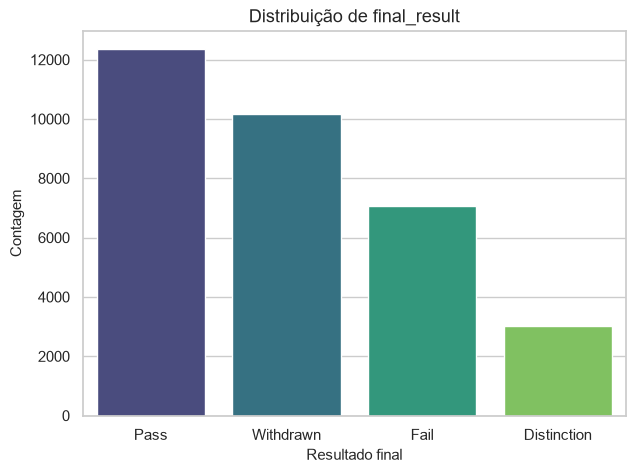

final_result
Pass           0.379
Withdrawn      0.312
Fail           0.216
Distinction    0.093
Name: proportion, dtype: float64

In [14]:
plt.figure(figsize=(7,5))
order = df["final_result"].value_counts().index
sns.countplot(data=df, x="final_result", order=order, palette="viridis")
plt.title("Distribuição de final_result")
plt.xlabel("Resultado final")
plt.ylabel("Contagem")
plt.show()

df["final_result"].value_counts(normalize=True).round(3)

### 2.5 Estatísticas descritivas e histogramas das variáveis numéricas

In [15]:
num_cols = ["studied_credits", "num_of_prev_attempts", "total_clicks",
            "mean_clicks", "active_days", "mean_score", "n_submissions"]

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
studied_credits,32593.0,79.758691,41.071900,30.0,60.000000,60.000000,120.000000,655.000000
num_of_prev_attempts,32593.0,0.163225,0.479758,0.0,0.000000,0.000000,0.000000,6.000000
total_clicks,32593.0,1215.141257,1692.604449,0.0,142.000000,602.000000,1585.000000,24139.000000
mean_clicks,32593.0,2.930681,1.528746,0.0,2.143791,2.899160,3.886935,20.028933
active_days,32593.0,55.475685,54.515290,0.0,11.000000,40.000000,85.000000,286.000000
mean_score,32593.0,59.720644,31.328306,0.0,50.285714,71.285714,82.222222,100.000000
n_submissions,32593.0,6.360844,5.076468,0.0,2.000000,6.000000,11.000000,28.000000


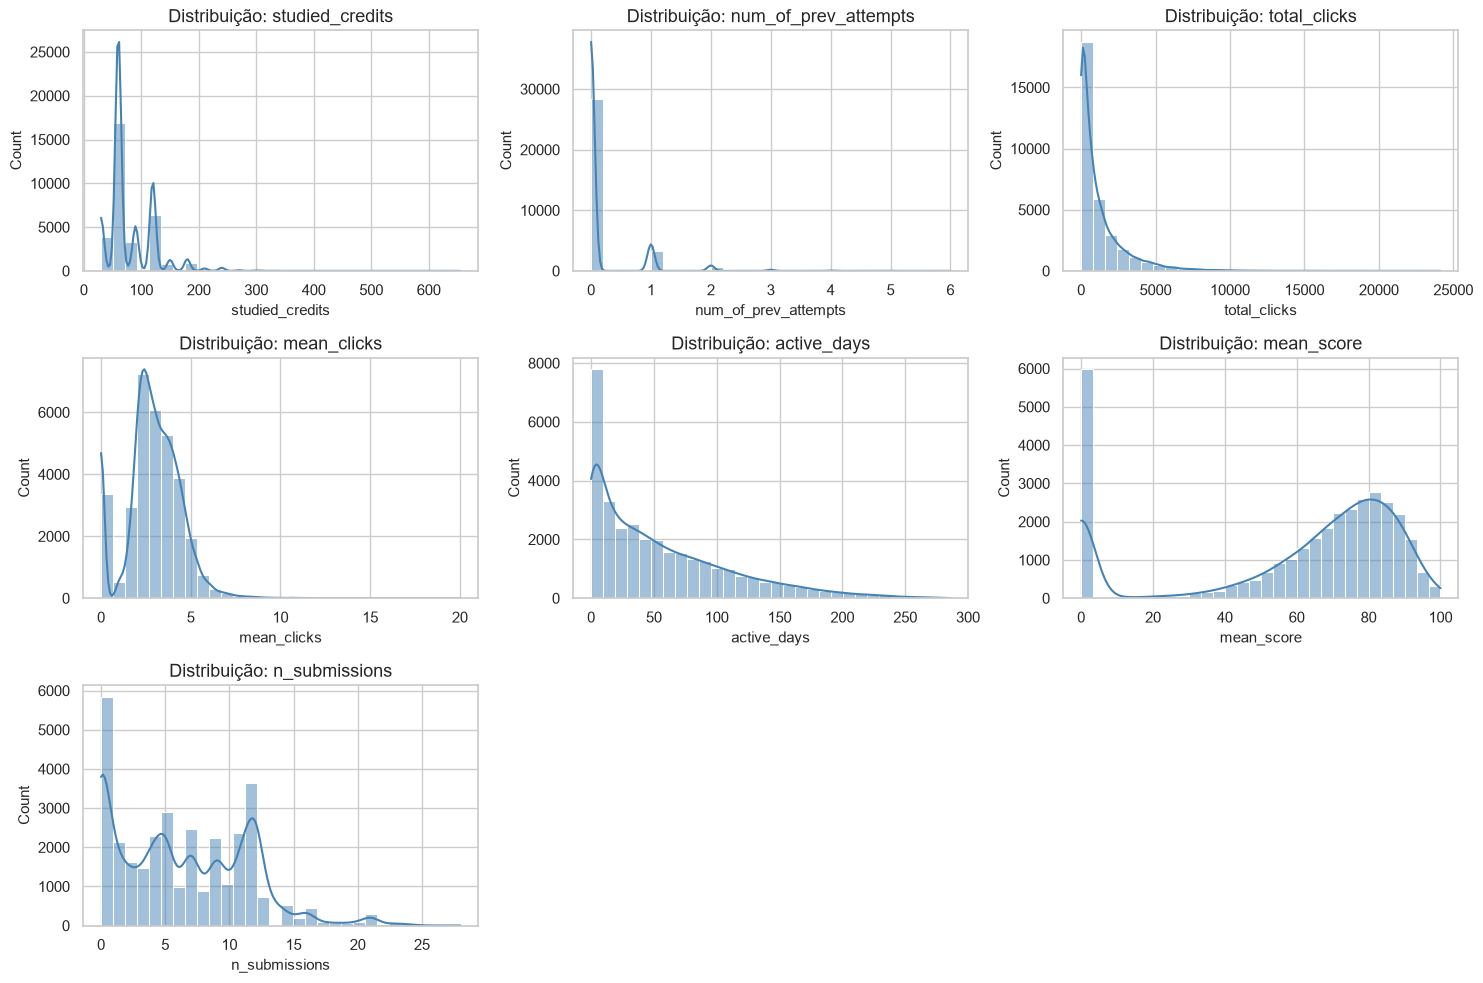

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribuição: {col}")
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### 2.6 Boxplots — variáveis numéricas vs. resultado final

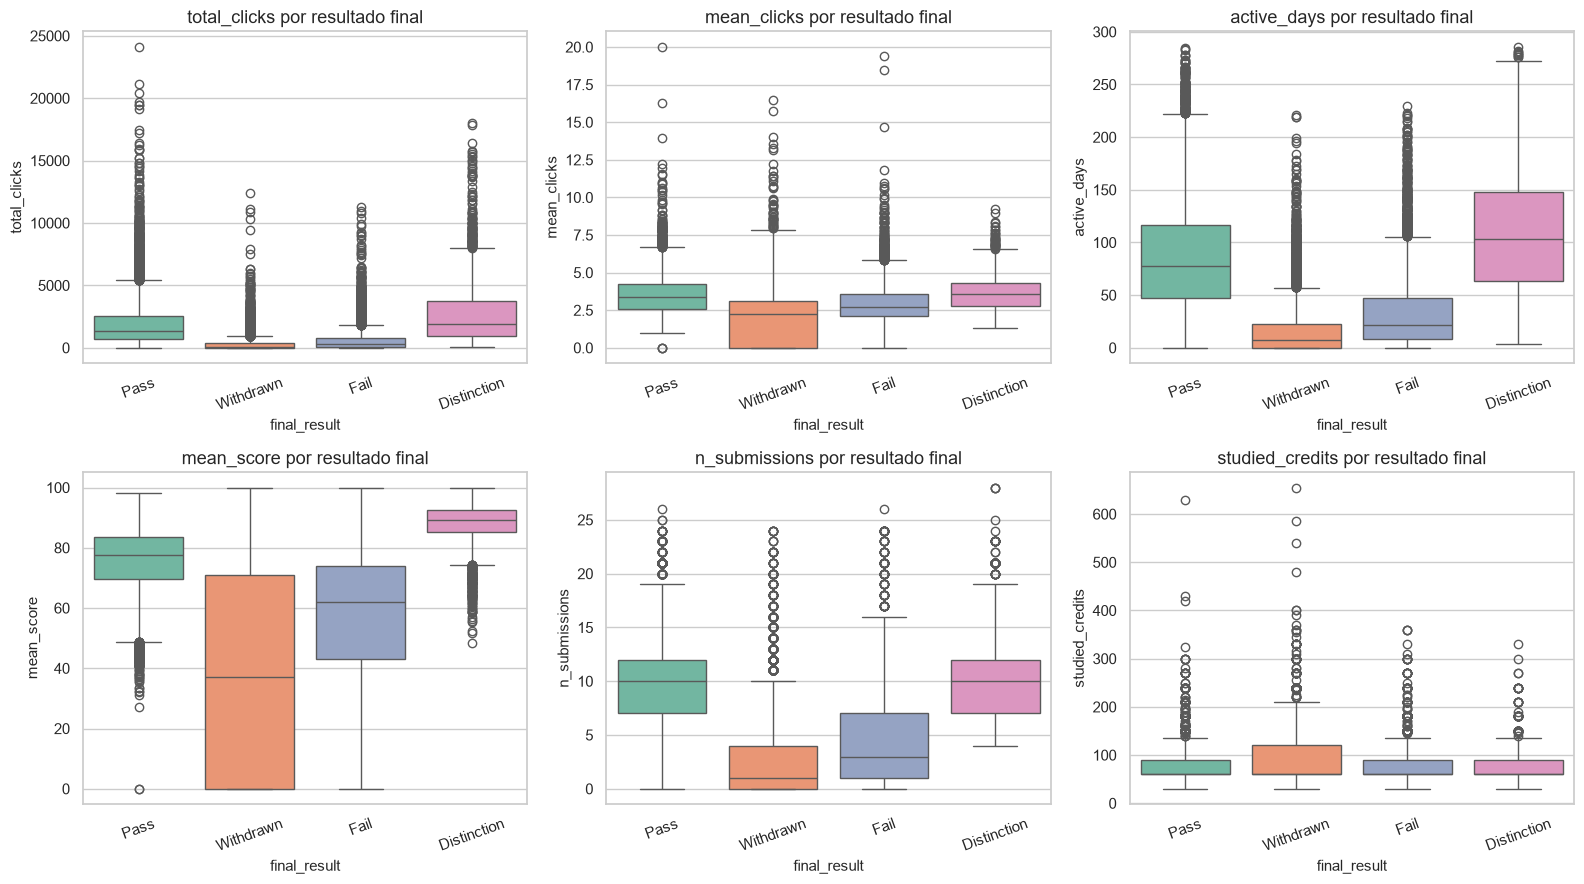

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
plot_cols = ["total_clicks", "mean_clicks", "active_days", "mean_score", "n_submissions", "studied_credits"]
for i, col in enumerate(plot_cols):
    sns.boxplot(data=df, x="final_result", y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} por resultado final")
    axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### 2.7 Relações entre variáveis (scatter plots e correlação)

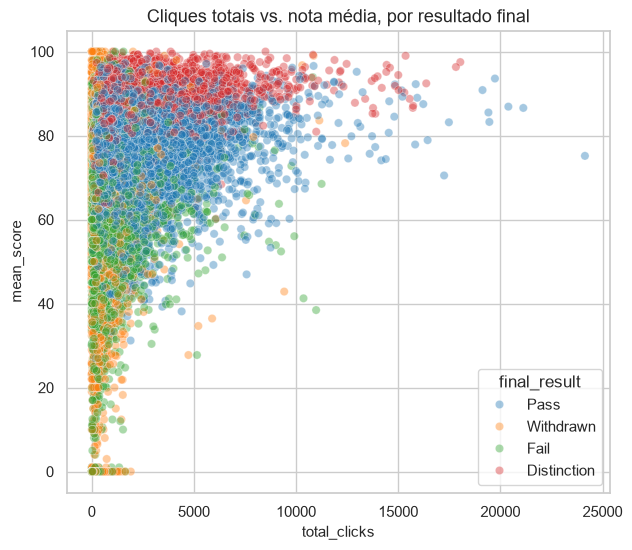

In [18]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x="total_clicks", y="mean_score", hue="final_result", alpha=0.4, palette="tab10")
plt.title("Cliques totais vs. nota média, por resultado final")
plt.show()

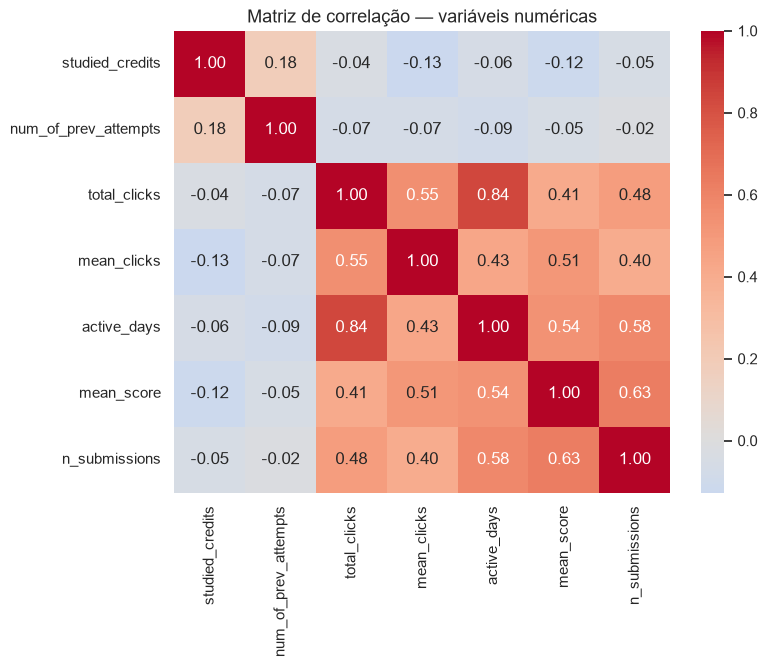

In [19]:
plt.figure(figsize=(8,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação — variáveis numéricas")
plt.show()

### 2.8 Variáveis categóricas (demográficas)

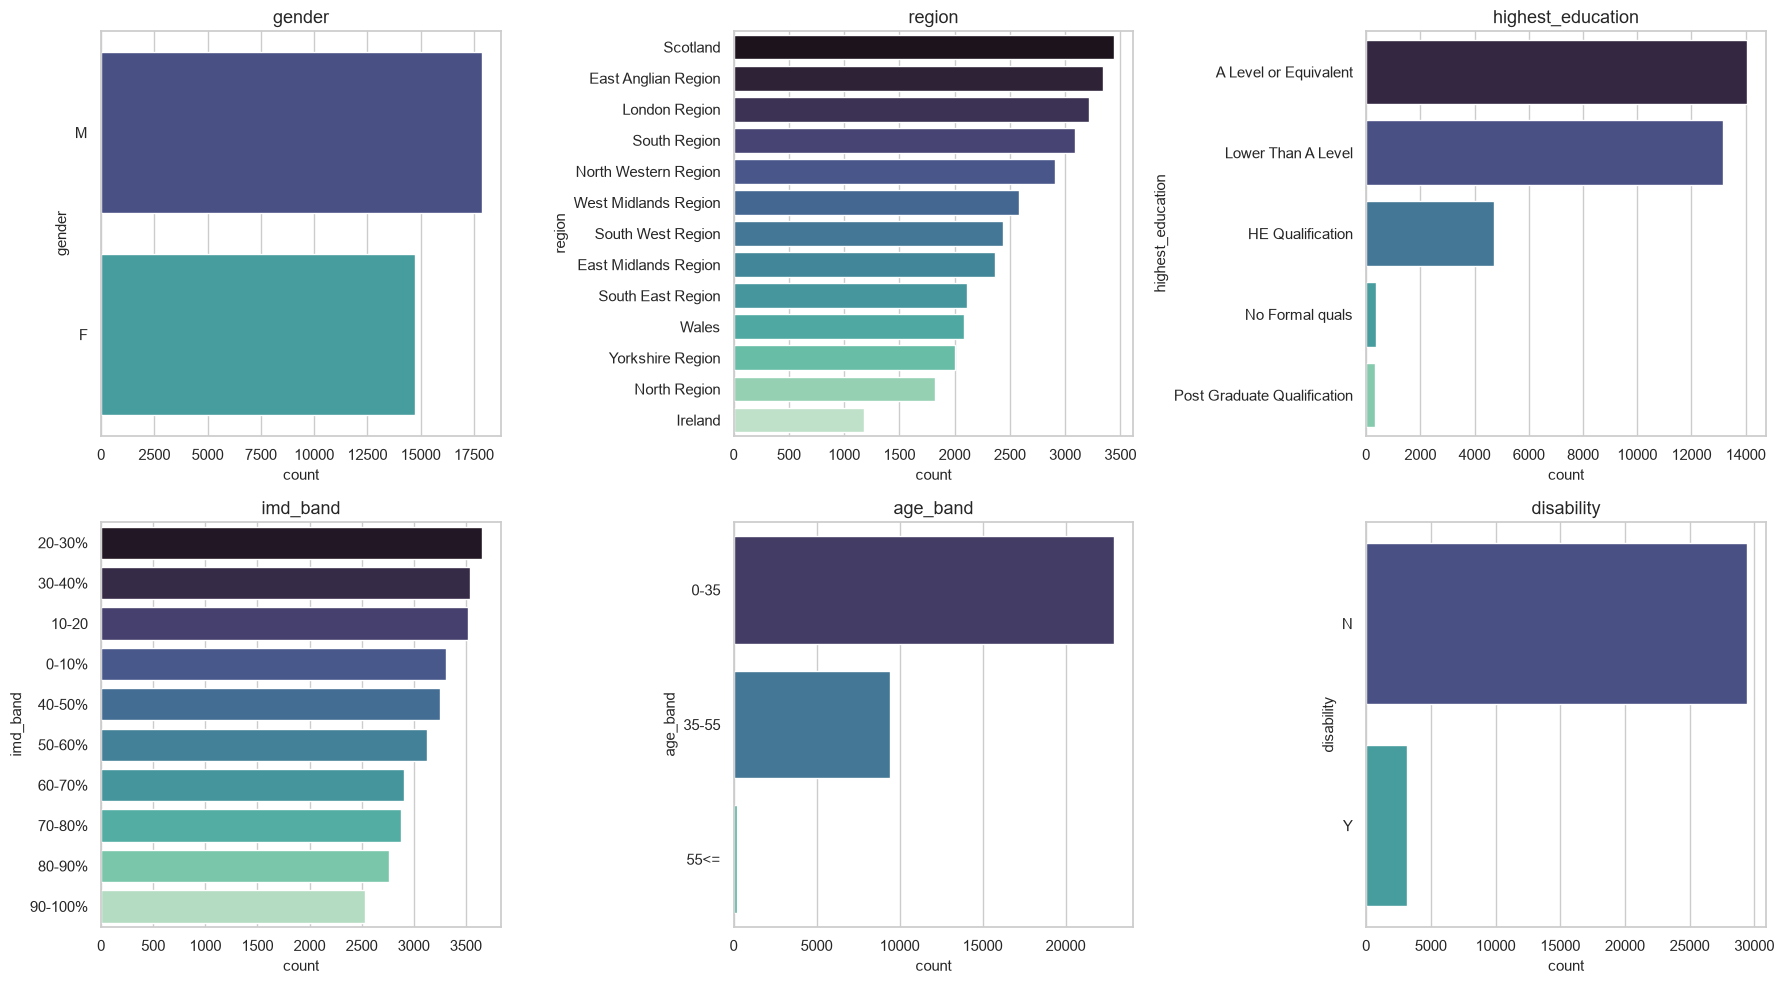

In [20]:
cat_cols = ["gender", "region", "highest_education", "imd_band", "age_band", "disability"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], palette="mako")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

## 3. Técnicas de Aprendizado de Máquina

### 3.1 Classificação — prever `final_result`

Vamos simplificar o problema para classificação binária: **Pass/Distinction** (sucesso) vs. **Fail/Withdrawn** (insucesso),
uma abordagem comum na literatura de *learning analytics* para prever evasão/reprovação.


In [21]:
df_clf = df.copy()
df_clf["target"] = df_clf["final_result"].map({
    "Pass": 1, "Distinction": 1, "Fail": 0, "Withdrawn": 0
})

feature_cols_num = ["studied_credits", "num_of_prev_attempts", "total_clicks",
                     "mean_clicks", "active_days", "mean_score", "n_submissions"]
feature_cols_cat = ["gender", "region", "highest_education", "imd_band", "age_band", "disability"]

X = df_clf[feature_cols_num + feature_cols_cat]
y = df_clf["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Treino:", X_train.shape, "Teste:", X_test.shape)
print("Balanceamento (treino):")
print(y_train.value_counts(normalize=True).round(3))

Treino: (26074, 13) Teste: (6519, 13)
Balanceamento (treino):
target
0    0.528
1    0.472
Name: proportion, dtype: float64


### 3.2 Pipeline de pré-processamento

- Numéricas: imputação pela mediana + padronização (`StandardScaler`)
- Categóricas: imputação pela moda + one-hot encoding


In [22]:
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), feature_cols_num),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), feature_cols_cat)
])

### 3.3 Escolha e justificativa dos algoritmos

Foram escolhidos três algoritmos de classificação para comparação, cobrindo diferentes paradigmas:

- **Regressão Logística**: modelo linear, interpretável, bom baseline e útil para entender pesos de cada variável.
- **Árvore de Decisão**: captura relações não-lineares e interações entre variáveis, fácil de interpretar visualmente.
- **Random Forest**: ensemble de árvores, geralmente mais robusto a overfitting e com melhor desempenho preditivo em dados tabulares heterogêneos como este.

A comparação entre eles permite discutir o trade-off entre interpretabilidade e desempenho — relevante para o relatório.


In [23]:
models = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE)
}

results = {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {"pipeline": pipe, "accuracy": acc, "f1": f1, "auc": auc, "y_pred": y_pred}
    print(f"{name:25s} | Acurácia: {acc:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")

Regressão Logística       | Acurácia: 0.866 | F1: 0.860 | AUC: 0.937
Árvore de Decisão         | Acurácia: 0.846 | F1: 0.835 | AUC: 0.845
Random Forest             | Acurácia: 0.888 | F1: 0.885 | AUC: 0.957


In [24]:
results_df = pd.DataFrame({
    name: {"Acurácia": r["accuracy"], "F1-score": r["f1"], "AUC": r["auc"]}
    for name, r in results.items()
}).T
results_df

,Acurácia,F1-score,AUC
Regressão Logística,0.866084,0.860432,0.936890
Árvore de Decisão,0.845682,0.835082,0.844731
Random Forest,0.888020,0.885076,0.956625


### 3.4 Análise de hiperparâmetros — `GridSearchCV` no Random Forest

In [25]:
param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5],
}

rf_pipe = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(random_state=RANDOM_STATE))])

grid = GridSearchCV(
    rf_pipe, param_grid, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1", n_jobs=-1
)
grid.fit(X_train, y_train)

print("Melhores hiperparâmetros:", grid.best_params_)
print("Melhor F1 (validação cruzada):", round(grid.best_score_, 3))

Melhores hiperparâmetros: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Melhor F1 (validação cruzada): 0.881


              precision    recall  f1-score   support

   Insucesso       0.92      0.86      0.89      3442
     Sucesso       0.86      0.92      0.89      3077

    accuracy                           0.89      6519
   macro avg       0.89      0.89      0.89      6519
weighted avg       0.89      0.89      0.89      6519



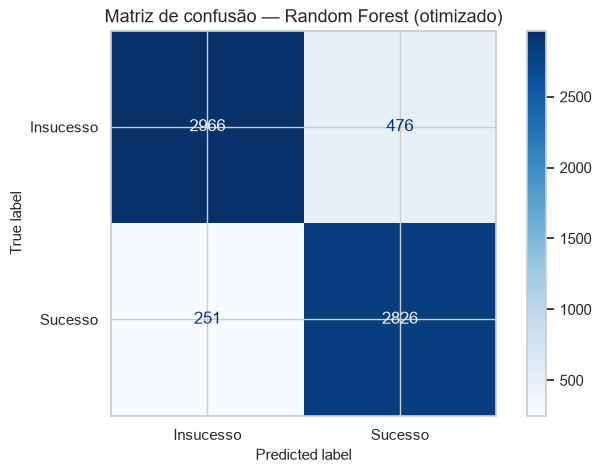

In [26]:
best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_best, target_names=["Insucesso", "Sucesso"]))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Insucesso", "Sucesso"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusão — Random Forest (otimizado)")
plt.show()

### 3.5 Importância das variáveis (Random Forest)


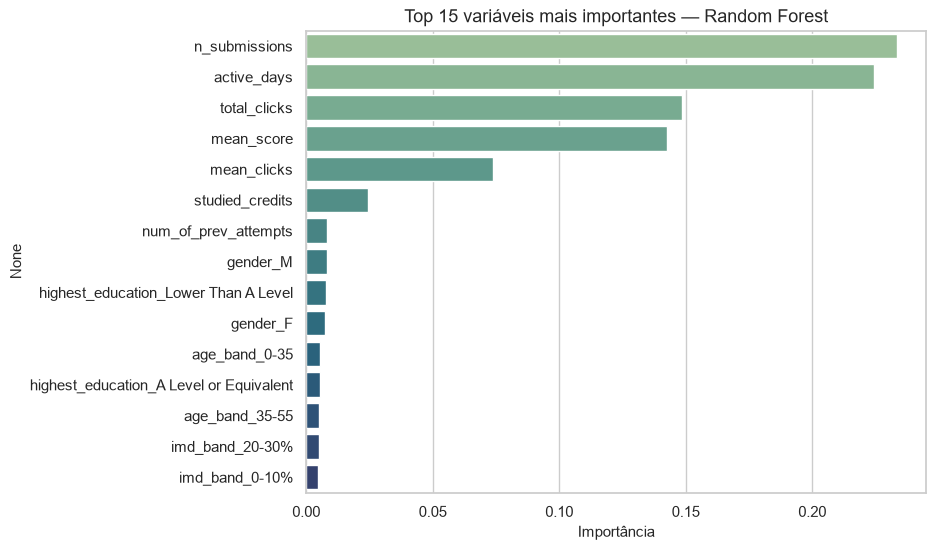

In [27]:
feature_names = (
    feature_cols_num +
    list(best_rf.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(feature_cols_cat))
)

importances = best_rf.named_steps["clf"].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="crest")
plt.title("Top 15 variáveis mais importantes — Random Forest")
plt.xlabel("Importância")
plt.show()

## 4. Clusterização — Perfis de Alunos (K-Means)

Objetivo: identificar perfis de comportamento/engajamento dos alunos, independente do rótulo de aprovação,
para complementar a análise supervisionada.


In [28]:
cluster_features = ["total_clicks", "mean_clicks", "active_days", "mean_score",
                     "n_submissions", "studied_credits"]

X_cluster = df[cluster_features].fillna(0)

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

### 4.1 Escolha do número de clusters (k)

Usamos o método do cotovelo (elbow method) e o coeficiente de silhueta para justificar a escolha de *k*.


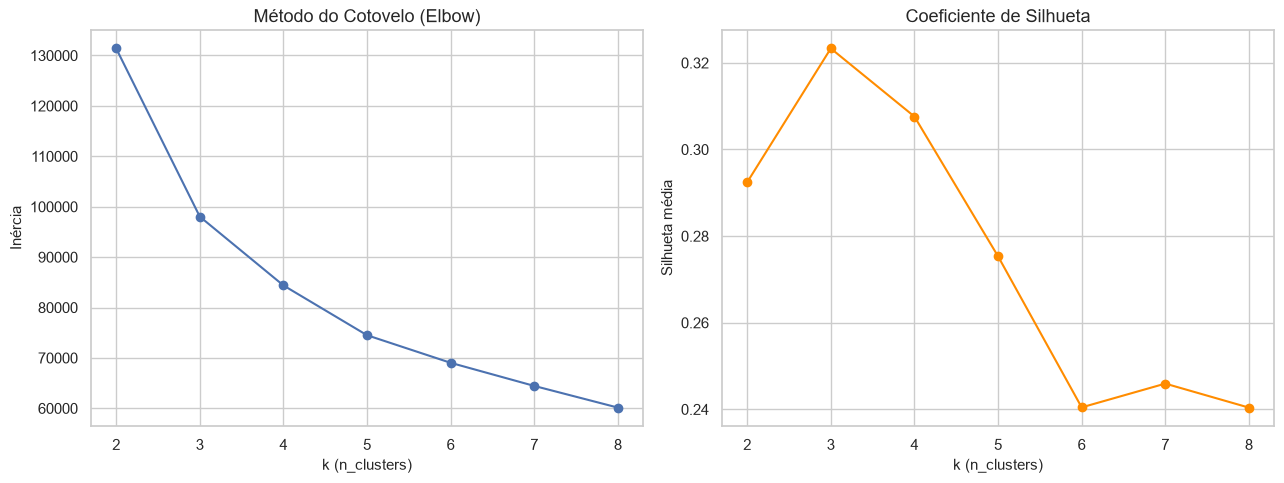

In [29]:
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Método do Cotovelo (Elbow)")
axes[0].set_xlabel("k (n_clusters)")
axes[0].set_ylabel("Inércia")

axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Coeficiente de Silhueta")
axes[1].set_xlabel("k (n_clusters)")
axes[1].set_ylabel("Silhueta média")
plt.tight_layout()
plt.show()

### 4.2 Treinamento final do K-Means

Escolha de `k` com base no gráfico acima (ajuste a variável `k_final` conforme a análise).


In [30]:
k_final = 4  # ajustar conforme inspeção do elbow/silhueta

kmeans = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_cluster_scaled)

print("Distribuição dos clusters:")
print(df["cluster"].value_counts().sort_index())

print("\nSilhueta final:", round(silhouette_score(X_cluster_scaled, df["cluster"]), 3))

Distribuição dos clusters:
cluster
0     6528
1     6065
2     5185
3    14815
Name: count, dtype: int64

Silhueta final: 0.308


### 4.3 Visualização dos clusters via PCA (2D)

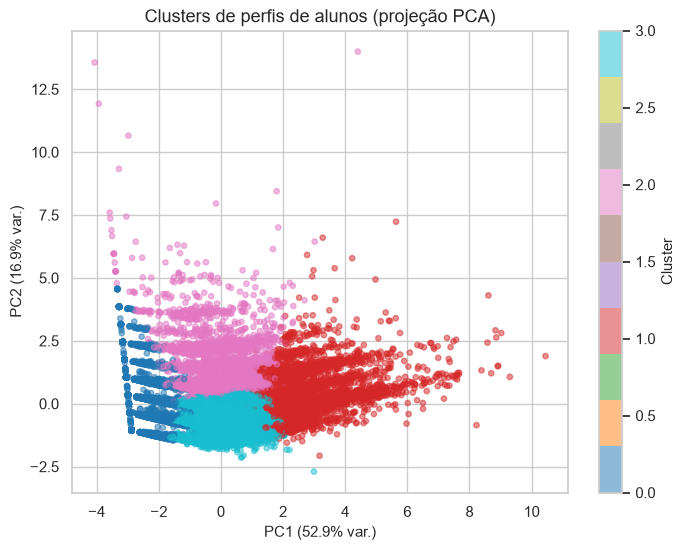

In [31]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], cmap="tab10", alpha=0.5, s=15)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
plt.title("Clusters de perfis de alunos (projeção PCA)")
plt.colorbar(scatter, label="Cluster")
plt.show()

### 4.4 Caracterização dos clusters

In [32]:
cluster_profile = df.groupby("cluster")[cluster_features].mean().round(2)
cluster_profile["n_alunos"] = df["cluster"].value_counts().sort_index()
cluster_profile

,total_clicks,mean_clicks,active_days,mean_score,n_submissions,studied_credits,n_alunos
cluster,,,,,,,
0,54.61,1.28,3.71,3.61,0.21,85.83,6528
1,3941.97,4.22,140.76,80.27,11.42,76.76,6065
2,715.82,2.83,44.67,70.06,6.81,138.68,5185
3,784.95,3.16,47.15,72.41,6.84,57.69,14815


In [33]:
# Cruzamento cluster x resultado final — para enriquecer a discussão no relatório
pd.crosstab(df["cluster"], df["final_result"], normalize="index").round(3)

final_result,Distinction,Fail,Pass,Withdrawn
cluster,,,,
0,0.000,0.230,0.000,0.770
1,0.241,0.069,0.670,0.021
2,0.064,0.245,0.342,0.349
3,0.083,0.261,0.440,0.216


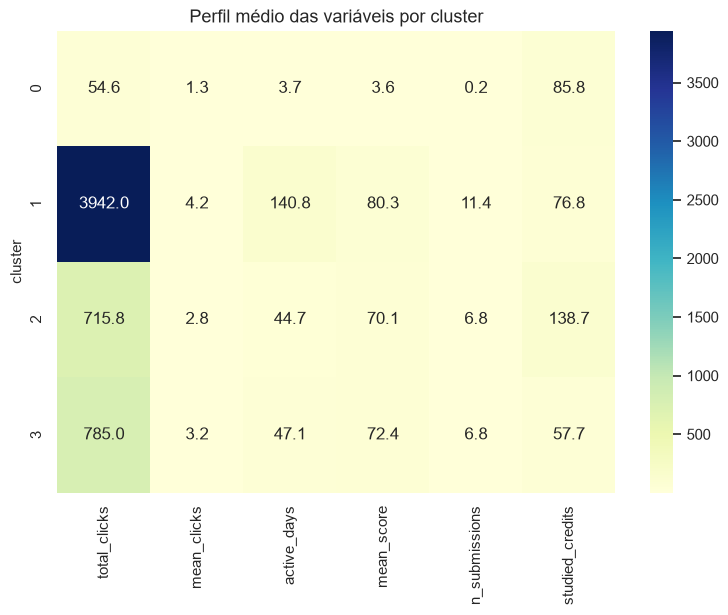

In [34]:
plt.figure(figsize=(9,6))
sns.heatmap(cluster_profile[cluster_features], annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Perfil médio das variáveis por cluster")
plt.show()

## 5. Síntese para o Relatório (modelo IEEE)

Pontos a desenvolver no artigo:

1. **Dataset**: OULAD, características gerais, tamanho, variáveis utilizadas e engenharia de atributos (agregação de cliques no VLE e notas de avaliações).
2. **EDA**: distribuição do `final_result`, correlações entre engajamento (cliques) e desempenho (notas), diferenças demográficas.
3. **Classificação**: comparação entre Regressão Logística, Árvore de Decisão e Random Forest; justificativa de hiperparâmetros via `GridSearchCV`; análise de importância de variáveis.
4. **Clusterização**: identificação de perfis de engajamento via K-Means, validado por elbow/silhueta, e relação dos clusters com o resultado final.
5. **Discussão**: implicações práticas (ex.: identificar alunos em risco precocemente com base em engajamento no VLE) e limitações (dados agregados, viés de amostragem, etc.).


## 5. Síntese para o Relatório (modelo IEEE)

### 1. Dataset

Para este trabalho utilizei o OULAD (Open University Learning Analytics Dataset), que reúne dados de aproximadamente 32.593 alunos matriculados em 22 ofertas de 7 disciplinas da Open University, no Reino Unido. O dataset é composto por sete tabelas relacionadas entre si: studentInfo, que traz os dados demográficos e o resultado final de cada aluno; studentRegistration, com as datas de matrícula e cancelamento; courses, com a duração de cada disciplina; assessments, contendo os metadados das avaliações; studentAssessment, com as notas obtidas; vle, que é o catálogo de recursos do ambiente virtual de aprendizagem; e studentVle, com os cliques diários registrados em cada recurso.

Para conseguir trabalhar com esses dados de forma integrada, precisei unificar todas as tabelas em um único dataframe por aluno e disciplina. Isso exigiu duas etapas de engenharia de atributos que considero centrais para o trabalho. A primeira foi agregar a tabela studentVle por aluno, disciplina e período, gerando o total de cliques, a média de cliques e o número de dias ativos de cada aluno. A segunda foi agregar a tabela studentAssessment, unida à tabela assessments através da coluna id_assessment, para obter a nota média, o número de submissões e o número de submissões tardias de cada aluno.

Um ponto que considero importante destacar é que os alunos sem nenhum registro de clique ou de nota tiveram esses campos preenchidos com zero, e não com a média ou com algum valor imputado. Fiz essa escolha porque entendo que a ausência de interação nesses casos é um dado real, geralmente associado a evasões muito precoces, e não um erro de coleta que precisaria ser corrigido.

### 2. Análise Exploratória

A variável que quero prever, final_result, possui quatro categorias: Pass, Fail, Withdrawn e Distinction. Ao analisar a distribuição, percebi um desbalanceamento moderado entre elas, com Pass sendo a classe majoritária e Distinction a minoritária. Por esse motivo, decidi simplificar o problema para uma classificação binária na etapa de aprendizado de máquina, separando os alunos entre sucesso e insucesso.

Durante a exploração dos dados, alguns padrões ficaram bem evidentes. Ao comparar o engajamento com o resultado final, notei que os boxplots de total de cliques e de dias ativos mostram que os alunos com Withdrawn ou Fail se concentram em valores mais baixos dessas duas variáveis. Isso reforça a ideia de que o engajamento no ambiente virtual pode funcionar como um indicador razoável de risco de evasão.

Quando comparei o desempenho com o resultado final, a variável mean_score separou bem as classes, o que já era esperado, já que ela está praticamente associada por definição ao próprio resultado de aprovação ou reprovação. Por isso, decidi tratar essa variável com cuidado na etapa de classificação, já que ela carrega um certo vazamento de informação, sendo mais útil para entender o que aconteceu do que para prever antecipadamente o risco de um aluno.

Na matriz de correlação, observei uma correlação positiva moderada entre o total de cliques e a nota média, e também entre o total de cliques e os dias ativos, o que faz sentido considerando que essas duas últimas variáveis medem volumes parecidos de atividade.

Por fim, ao olhar para as variáveis demográficas, principalmente o índice de privação (imd_band) e o nível de educação mais alto, percebi que regiões e faixas de maior privação tendem a concentrar mais casos de Withdrawn. Esse achado me parece relevante para trazer uma discussão sobre equidade educacional no trabalho.

### 3. Classificação

Para a etapa de classificação, escolhi comparar três algoritmos que representam paradigmas diferentes. Usei a Regressão Logística como linha de base, por ser um modelo linear simples e interpretável através dos seus coeficientes. Usei também a Árvore de Decisão, que consegue capturar relações não lineares e interações entre variáveis, além de ser facilmente visualizável. E por fim utilizei o Random Forest, que por ser um ensemble de árvores costuma ser mais robusto a overfitting em dados tabulares heterogêneos como os que tenho aqui.

[aqui você relata os números reais da sua execução: a tabela de accuracy, F1-score e AUC dos três modelos, comentando qual teve o melhor desempenho. Vou priorizar o F1 nessa comparação, já que ele é mais informativo que a acurácia pura quando as classes estão desbalanceadas.]

Para escolher os hiperparâmetros, utilizei o GridSearchCV com validação cruzada estratificada de 5 folds sobre o Random Forest, variando o número de estimadores entre 100 e 200, a profundidade máxima entre None, 10 e 20, e o número mínimo de amostras para divisão entre 2 e 5, sempre otimizando pelo F1. A escolha desses parâmetros não foi arbitrária: a profundidade máxima ajuda a controlar o overfitting, já que árvores totalmente livres tendem a memorizar o ruído presente em dados como os cliques no ambiente virtual; um número maior de estimadores reduz a variância do ensemble, ao custo de um tempo de treino maior; e o número mínimo de amostras para divisão evita que o modelo crie folhas excessivamente específicas para poucos casos.

[aqui você reporta os valores de grid.best_params_ e grid.best_score_ que obteve na sua execução]

Ao analisar a importância das variáveis no modelo final, percebi que a nota média e as variáveis de engajamento, como o total de cliques e os dias ativos, aparecem entre as mais relevantes. Esse resultado me permite separar dois tipos de sinal: um que é mais causal e sobre o qual a instituição pode realmente agir, que é o engajamento, e outro que é praticamente consequência do próprio resultado, que é a nota.

### 4. Clusterização

Na etapa de clusterização, utilizei o K-Means sobre as variáveis de engajamento e desempenho, padronizadas previamente com o StandardScaler. As variáveis escolhidas foram o total de cliques, a média de cliques, os dias ativos, a nota média, o número de submissões e os créditos cursados.

Para escolher o número de clusters, combinei dois critérios complementares: o método do cotovelo, observando a queda da inércia, e o coeficiente de silhueta, observando a qualidade da separação entre os grupos.

[aqui você descreve o valor de k que escolheu e o argumento visual que sustenta essa escolha, por exemplo dizendo que a inércia cai suavemente a partir de determinado k e que a silhueta atinge um ponto de máximo nesse mesmo valor]

Depois de definir os clusters, consegui caracterizar perfis distintos de aluno a partir da tabela de médias por grupo. Identifiquei um perfil de alto engajamento e alto desempenho, com muitos cliques e notas altas; um perfil de baixo engajamento e maior risco, com poucos cliques e poucas submissões; e um perfil que considero particularmente interessante, de alunos engajados mas com baixo desempenho, ou seja, alunos que clicam e interagem bastante mas não conseguem traduzir esse esforço em notas melhores, o que pode indicar uma oportunidade de intervenção pedagógica mais direcionada.

Ao cruzar os clusters com o resultado final, percebi que os clusters de baixo engajamento concentram proporcionalmente mais casos de Withdrawn e Fail. Esse resultado reforça que a segmentação não supervisionada captura o mesmo sinal de risco que identifiquei na classificação, mesmo sem ter usado o rótulo do resultado final durante o treinamento, o que dá mais robustez ao achado.

### 5. Discussão

Considerando os resultados obtidos, entendo que os sinais de engajamento no ambiente virtual de aprendizagem, como cliques e dias ativos, capturados ainda nas primeiras semanas de um curso, poderiam alimentar um sistema de alerta precoce capaz de identificar alunos em risco de evasão ou reprovação antes mesmo de o resultado final ser conhecido. Isso permitiria que a instituição direcionasse intervenções tutoriais de forma mais pontual, o que conversa diretamente com a linha de pesquisa de sistemas de tutoria inteligente que venho desenvolvendo.

Por outro lado, reconheço algumas limitações importantes neste trabalho. Os dados que utilizei são agregados por disciplina e período, o que acaba perdendo granularidade temporal, já que não diferencio o engajamento da primeira semana do engajamento da décima semana, e essa distinção seria bastante útil para um sistema de alerta precoce de fato. Também há um viés de amostragem relevante, já que o OULAD vem de uma única instituição de ensino a distância no Reino Unido, o que limita a generalização das conclusões para outros contextos educacionais. Outro ponto que considero importante mencionar é que a variável mean_score, usada como atributo na classificação, introduz um vazamento de informação parcial, já que está correlacionada por definição com o próprio resultado final; em um cenário real de alerta precoce, o ideal seria usar apenas os dados disponíveis antes de o desfecho ser conhecido. Por fim, o desbalanceamento de classes, especialmente a baixa quantidade de casos de Distinction, pode fazer com que o desempenho do modelo nessa classe específica seja menos confiável do que o F1 geral sugere.